In [1]:
# Imports

import pyglet
pyglet.options["headless"] = True


import warp as wp

import numpy as np
import pickle


from waxmorph import simulator, render
from importlib import reload

from sklearn.preprocessing import MinMaxScaler
from tqdm import trange

import pyvista as pv
import os


# Configure these according to your system, see the PyVista page for details
# Alternatively, just replace the backend to be 'html'

# pv.global_theme.trame.jupyter_extension_enabled = True
# pv.global_theme.trame.server_proxy_enabled = False
# os.environ["PYVISTA_OFF_SCREEN"] = "true"
pv.set_jupyter_backend('html')  # change this to html for better experience



def fibonacci_sphere_points(num_points, radius):
    points = np.zeros((num_points, 3))
    phi = np.pi * (3. - np.sqrt(5.))

    for i in range(num_points):
        y = 1 - (i / float(num_points - 1)) * 2 
        r = np.sqrt(1 - y * y) 
        theta = phi * i 

        x = np.cos(theta) * r
        z = np.sin(theta) * r

        points[i] = [x * radius, y * radius, z * radius]

    return points


def uniform_ball_points(n, R):
    v = np.random.normal(size=(n, 3))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    radii = (np.random.rand(n) ** (1/3)) * R  # uniform in volume
    return v * radii[:, None]


def save_state(centers, radii, radii_eq, activators, inhibitors, particle_count, fname):
    with open(f'Checkpoints/{fname}.pkl', 'wb') as f:
        pickle.dump((centers, radii, radii_eq, activators, inhibitors, particle_count), f)


def load_state(fname):
    with open(f'Checkpoints/{fname}.pkl', 'rb') as f:
        state = pickle.load(f)

    return state

wp.init()
wp.clear_kernel_cache()
wp.clear_lto_cache()
np.random.seed(42)

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 12.4
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA H100 PCIe" (79 GiB, sm_90, mempool enabled)
   Kernel cache:
     /insomnia001/home/ob2391/.cache/warp/1.12.0


## Setup

In [2]:
# Sample points in space
particle_count = 100
max_particles = 80000
centers, radii, radii_eq, activators, inhibitors = np.full((max_particles, 3), np.array([0.,0.,0.])), np.full((max_particles,), -1000.), np.full((max_particles,), -1000.), np.full((max_particles,), 0.), np.full((max_particles,), 0.)

rad_proto = np.full((particle_count,), 0.6) 

radii[:particle_count] = rad_proto
radii_eq[:particle_count] = rad_proto


# Chemicals
act_mu = (((rad_proto**3) * 0.75) / 2.).mean()
inhib_mu = (((rad_proto**3) * 0.75) / 10.).mean()
act_sigma, inhib_sigma = 0.001, 0.001


activators[:particle_count] = act_mu + act_sigma * np.random.normal(size=(particle_count,))
inhibitors[:particle_count] = inhib_mu + inhib_sigma * np.random.normal(size=(particle_count,))


# CENTERS
prop = 7.

N_mes = int(particle_count / prop)
N_epi = particle_count - N_mes

R_shell = 3.
R_inner = R_shell - 1.2

centers[:N_mes] = uniform_ball_points(N_mes, R_inner)
centers[N_mes:particle_count] = fibonacci_sphere_points(N_epi, R_shell)

centers[:particle_count] += 0.05 * np.random.normal(size=(particle_count, 3))


# polarities
polarities = np.ones((max_particles, 3), dtype=np.float64) / np.sqrt(3)
vesicle_center = centers[:particle_count].mean(axis=0)


p = centers[:particle_count] - vesicle_center
norms = np.linalg.norm(p, axis=1, keepdims=True)
polarities[:particle_count] = p / np.clip(norms, 1e-12, None)

# cell types
cell_types = np.full((max_particles,), 3, dtype=np.uint32)
cell_types[:N_mes] = 0
cell_types[N_mes:particle_count] = 1

# Zero out epithelia concentrations
activators[N_mes:particle_count] = 0.
inhibitors[N_mes:particle_count] = 0.


keys_proto = simulator.gen_key_array(max_particles)


# plotter = render.PyVistaInterface.draw_3d_view(centers, radii, MinMaxScaler(feature_range=(0, 0.9)).fit_transform((activators * 0.75 / (radii**3)).reshape(-1,1)).flatten(), polarities, particle_count, blim=-15, tlim=15, alpha=1, polarity_length=3., cell_types=cell_types)
# plotter.show()

Module waxmorph.simulator 2cc6c86 load on device 'cuda:0' took 2147.93 ms  (compiled)


## Polarize

In [ ]:
R = wp.from_numpy(radii,   dtype=wp.float32, device="cuda")
X = wp.from_numpy(centers, dtype=wp.vec3f, device="cuda")
P = wp.from_numpy(polarities, dtype=wp.vec3f, device="cuda")
CT = wp.from_numpy(cell_types, dtype=wp.uint32, device="cuda")

dt_mech = 1e-2

X_pass = wp.zeros_like(X, device="cuda")

for i in trange(1000):
    simulator.mech_step_sticky(X, R, P, CT, particle_count, dt_mech, X_pass, P, grad_consist=False)

In [ ]:
plotter = render.PyVistaInterface.draw_3d_view(X.numpy(), R.numpy(), MinMaxScaler(feature_range=(0, 0.9)).fit_transform((activators * 0.75 / (radii**3)).reshape(-1,1)).flatten(), P.numpy(), particle_count, blim=-15, tlim=15, alpha=1, polarity_length=3., cell_types=CT.numpy())
plotter.show()

## Move

In [ ]:
R = wp.from_numpy(radii,   dtype=wp.float32, device="cuda")
X = wp.from_numpy(centers, dtype=wp.vec3f, device="cuda")
P = wp.from_numpy(polarities, dtype=wp.vec3f, device="cuda")
CT = wp.from_numpy(cell_types, dtype=wp.uint32, device="cuda")
A = wp.from_numpy(activators,   dtype=wp.float32, device="cuda")
I = wp.from_numpy(inhibitors, dtype=wp.float32, device="cuda")

dt_mech=5e-2


with render.WarpMovieRenderer(
    filename="Output/Turing/typed_polarization_move_autodiff_last.usd",
    max_particles=max_particles,
    width=1920,
    height=1080,
    fps=60,
    device="cuda",
) as mov:

    for t in trange(1000):
        simulator.mech_step_sticky_implicit(X, R, P, CT, particle_count, dt_mech, X, P)
    

        mov.write_frame_from_state(
            t=t,
            centers_wp=X,
            radii_wp=R,
            A_wp=A,
            I_wp=I,
            particle_count=particle_count,
            morph="ratio",          # "A" or "I" or "ratio"
            morph_scale=1.,   
            hue=0.80,
        )

In [ ]:
plotter = render.PyVistaInterface.draw_3d_view(X.numpy(), R.numpy(), MinMaxScaler(feature_range=(0, 0.9)).fit_transform((activators * 0.75 / (radii**3)).reshape(-1,1)).flatten(), P.numpy(), particle_count, blim=-15, tlim=15, alpha=1, polarity_length=3., cell_types=CT.numpy())
plotter.show()

## Chemicals

In [ ]:
A = wp.from_numpy(activators,   dtype=wp.float32, device="cuda")
I = wp.from_numpy(inhibitors, dtype=wp.float32, device="cuda")
R = wp.from_numpy(radii,   dtype=wp.float32, device="cuda")
X = wp.from_numpy(centers, dtype=wp.vec3f, device="cuda")
P = wp.from_numpy(polarities, dtype=wp.vec3f, device="cuda")
CT = wp.from_numpy(cell_types, dtype=wp.uint32, device="cuda")

S = wp.full(1, value=2e-2, dtype=wp.float32)
T = wp.full(1, value=1e-2, dtype=wp.float32)
phi = 10.

dt_chem=1e-1

lapA, lapI = wp.zeros_like(A, device="cuda"), wp.zeros_like(I, device="cuda")

a_s, i_s = [], []

for i in trange(10000):
    simulator.mech_step_sticky(X, R, P, CT, particle_count, dt_mech, X, P, grad_consist=False)



with render.WarpMovieRenderer(
    filename="Output/Turing/gene_patterning_example.usd",
    max_particles=max_particles,
    width=1920,
    height=1080,
    fps=60,
    device="cuda",
) as mov:

    
    for t in trange(50000):
        lapA.zero_()
        lapI.zero_()
        
        simulator.chem_step(A, I, X, R, lapA, lapI, S, T, phi, dt_chem, particle_count, A, I, grad_consist=False)
        
        a_s.append(A.numpy())
        i_s.append(I.numpy())


        mov.write_frame_from_state(
            t=t,
            centers_wp=X,
            radii_wp=R,
            A_wp=A,
            I_wp=I,
            particle_count=particle_count,
            morph="ratio",          # "A" or "I" or "ratio"
            morph_scale=max(A.numpy().max(), I.numpy().max()),   
            hue=0.80,
        )

In [ ]:
import matplotlib.pyplot as plt
plt.plot([a_s[i][0] for i in range(len(a_s))])
plt.plot([i_s[i][0] for i in range(len(i_s))])

In [ ]:
plotter = render.PyVistaInterface.draw_3d_view(X.numpy(), R.numpy(), MinMaxScaler(feature_range=(0, 0.9)).fit_transform((A.numpy() * 0.75 / (R.numpy()**3)).reshape(-1,1)).flatten(), P.numpy(), particle_count, blim=-15, tlim=15, alpha=1, polarity_length=3.,  cell_types=CT.numpy())
plotter.show()

## Growth

In [ ]:
A = wp.from_numpy(activators,   dtype=wp.float32, device="cuda")
I = wp.from_numpy(inhibitors, dtype=wp.float32, device="cuda")
R = wp.from_numpy(radii,   dtype=wp.float32, device="cuda")
R_eq = wp.from_numpy(radii_eq,   dtype=wp.float32, device="cuda")
X = wp.from_numpy(centers, dtype=wp.vec3f, device="cuda")
P = wp.from_numpy(polarities, dtype=wp.vec3f, device="cuda")
CT = wp.from_numpy(cell_types, dtype=wp.uint32, device="cuda")

SC = wp.full(1, value=1e-1, dtype=wp.float32, requires_grad=True)
AP = wp.full(1, value=10., dtype=wp.float32, requires_grad=True)
R_ref = 0.60   # epithelial target radius
R_max = 0.85   # mes eq radius cap 

keys = simulator.gen_key_array(max_particles)

dt_growth = 1e-2 


for i in trange(10000):
    simulator.mech_step_sticky(X, R, P, CT, particle_count, dt_mech, X, P, grad_consist=False)


for t in trange(20000):
    simulator.mech_step_sticky(X, R, P, CT, particle_count, dt_mech, X, P, grad_consist=False)
    simulator.growth_step(R, R_eq, A, CT, keys, AP, SC, dt_growth, R_ref, R_max, particle_count, R, R_eq, grad_consist=False)

In [ ]:
plotter = render.PyVistaInterface.draw_3d_view(X.numpy(), R.numpy(), MinMaxScaler(feature_range=(0, 0.9)).fit_transform((A.numpy() * 0.75 / (R.numpy()**3)).reshape(-1,1)).flatten(), P.numpy(), particle_count, blim=-15, tlim=15, alpha=1, polarity_length=3., cell_types=CT.numpy())
plotter.show()

## Render - Full with division

In [ ]:
device="cuda"

A = wp.from_numpy(activators,   dtype=wp.float32, device=device)
I = wp.from_numpy(inhibitors, dtype=wp.float32, device=device)
R = wp.from_numpy(radii,   dtype=wp.float32, device=device)
R_eq = wp.from_numpy(radii_eq,   dtype=wp.float32, device=device)
X = wp.from_numpy(centers, dtype=wp.vec3f, device=device)
P = wp.from_numpy(polarities, dtype=wp.vec3f, device="cuda")
CT = wp.from_numpy(cell_types, dtype=wp.uint32, device="cuda")


# Buffers and keys
lapA, lapI = wp.zeros_like(A, device="cuda"), wp.zeros_like(I, device="cuda")
keys = wp.clone(keys_proto)
n_tot = wp.zeros(shape=max_particles, dtype=wp.int32, device=device)
n_epi = wp.zeros(shape=max_particles, dtype=wp.int32, device=device)
n_mes = wp.zeros(shape=max_particles, dtype=wp.int32, device=device)
pcount=particle_count


# Generic constants
dt_mech = 5e-2
dt_chem = 5e-2
dt_growth = 5e-3

R_ref = 0.6   # epithelial target radius 
R_max = 1.4   # mes eq radius cap
R_div_ref = 1.   # slightly above R_ref so mes has to grow before dividing

i=1.
tau=1.
tmax=1.
phi=10.

# Cell type constants
epi_max_neighbors = 6 # hexagonal packing in 2d
p_epi = 1.
substeps_chem_mech = 20  # run more steps to make sure everything is catching up

    
SC = wp.full(1, value=0.5, dtype=wp.float32, requires_grad=True)
AP = wp.full(1, value=10., dtype=wp.float32, requires_grad=True)
S = wp.full(1, value=5e-3, dtype=wp.float32)
T = wp.full(1, value=1e-3, dtype=wp.float32)  # Undulation = 1e-2

for t in trange(10000):
    simulator.mech_step_sticky(X, R, P, CT, pcount, dt_mech, X, P, grad_consist=False)

for t in trange(50000):
    lapA.zero_()
    lapI.zero_()
    # PDEs
    simulator.chem_step(A, I, X, R, lapA, lapI, S, T, phi, dt_chem, pcount, A, I, grad_consist=False)
    


t = 0

with render.WarpMovieRenderer(
    filename="Output/Turing/branching_80k_newer.usd",
    max_particles=max_particles,
    width=1920,
    height=1080,
    fps=60,
    device="cuda",
) as mov:

    while pcount < int(0.9 * max_particles):
        lapA.zero_()
        lapI.zero_()
    
        # PDEs
        for _ in range(substeps_chem_mech):
            simulator.mech_step_sticky(X, R, P, CT, pcount, dt_mech, X, P, grad_consist=False)
            simulator.chem_step(A, I, X, R, lapA, lapI, S, T, phi, dt_chem, pcount, A, I, grad_consist=False)
        
        simulator.growth_step(R, R_eq, A, CT, keys, AP, SC, dt_growth, R_ref, R_max, pcount, R, R_eq, grad_consist=False)
    
        # Buffers
        n_tot.zero_()
        n_epi.zero_()
        n_mes.zero_()
        
        # counts
        simulator.count_neighbors_step(X, R, CT, pcount, n_tot, n_epi, n_mes, device=device)
        
        # Divide
        div_count = wp.full(1, value=pcount, dtype=wp.int32, device=device)
        div_slots = wp.full(pcount, value=-1, dtype=wp.int32, device=device)
        
                
        wp.launch(
            simulator.division_decision,
            dim=pcount,
            inputs=[
                X, R, CT, keys,
                n_epi, n_mes,
                div_count, div_slots,
                R_div_ref, p_epi, epi_max_neighbors,
                i, tmax, tau,
                max_particles
            ],
            device=device,
        )
        
        
        wp.launch(
            simulator.division_logic,
            dim=pcount,
            inputs=[
                X, R, R_eq, A, I,
                P, CT, div_slots,
            ],
            device=device,
        )
                
        pcount = min(div_count.numpy().item(), max_particles)
            
    
        mov.write_frame_from_state(
            t=t,
            centers_wp=X,
            radii_wp=R,
            A_wp=A,
            I_wp=I,
            particle_count=int(pcount),
            morph="A",          # "A" or "I" or "ratio"
            morph_scale=1.,   
            hue=0.80,
        )

        t += 1
        print(f"Time : {t}  //  Particles: {pcount}", end='\r')

## Render - Autograd

In [ ]:
device="cuda"

A = wp.from_numpy(activators,   dtype=wp.float32, device=device)
I = wp.from_numpy(inhibitors, dtype=wp.float32, device=device)
R = wp.from_numpy(radii,   dtype=wp.float32, device=device)
R_eq = wp.from_numpy(radii_eq,   dtype=wp.float32, device=device)
X = wp.from_numpy(centers, dtype=wp.vec3f, device=device)
P = wp.from_numpy(polarities, dtype=wp.vec3f, device="cuda")
CT = wp.from_numpy(cell_types, dtype=wp.uint32, device="cuda")


# Buffers and keys
lapA, lapI = wp.zeros_like(A, device="cuda"), wp.zeros_like(I, device="cuda")
keys = wp.clone(keys_proto)
n_tot = wp.zeros(shape=max_particles, dtype=wp.int32, device=device)
n_epi = wp.zeros(shape=max_particles, dtype=wp.int32, device=device)
n_mes = wp.zeros(shape=max_particles, dtype=wp.int32, device=device)
pcount=particle_count


# Generic constants
dt_mech = 5e-2
dt_chem = 5e-2
dt_growth = 5e-3

R_ref = 0.6   # epithelial target radius 
R_max = 1.4   # mes eq radius cap
R_div_ref = 1.   # slightly above R_ref so mes has to grow before dividing

i=1.
tau=1.
tmax=1.
phi=10.

# Cell type constants
epi_max_neighbors = 6 # hexagonal packing in 2d
p_epi = 1.
substeps_chem_mech = 20  # run more steps to make sure everything is catching up

    
SC = wp.full(1, value=0.5, dtype=wp.float32, requires_grad=True)
AP = wp.full(1, value=10., dtype=wp.float32, requires_grad=True)
S = wp.full(1, value=5e-3, dtype=wp.float32)
T = wp.full(1, value=1e-3, dtype=wp.float32)  # Undulation = 1e-2

for t in trange(10000):
    simulator.mech_step_sticky_implicit(X, R, P, CT, pcount, dt_mech, X, P)

for t in trange(50000):
    lapA.zero_()
    lapI.zero_()
    # PDEs
    simulator.chem_step(A, I, X, R, lapA, lapI, S, T, phi, dt_chem, pcount, A, I, grad_consist=False)
    


t = 0

with render.WarpMovieRenderer(
    filename="Output/Turing/branching_80k_autodiff.usd",
    max_particles=max_particles,
    width=1920,
    height=1080,
    fps=60,
    device="cuda",
) as mov:

    while pcount < int(0.9 * max_particles):
        lapA.zero_()
        lapI.zero_()
    
        # PDEs
        for _ in range(substeps_chem_mech):
            simulator.mech_step_sticky_implicit(X, R, P, CT, pcount, dt_mech, X, P)
            simulator.chem_step(A, I, X, R, lapA, lapI, S, T, phi, dt_chem, pcount, A, I, grad_consist=False)
        
        simulator.growth_step(R, R_eq, A, CT, keys, AP, SC, dt_growth, R_ref, R_max, pcount, R, R_eq, grad_consist=False)
    
        # Buffers
        n_tot.zero_()
        n_epi.zero_()
        n_mes.zero_()
        
        # counts
        simulator.count_neighbors_step(X, R, CT, pcount, n_tot, n_epi, n_mes, device=device)
        
        # Divide
        div_count = wp.full(1, value=pcount, dtype=wp.int32, device=device)
        div_slots = wp.full(pcount, value=-1, dtype=wp.int32, device=device)
        
                
        wp.launch(
            simulator.division_decision,
            dim=pcount,
            inputs=[
                X, R, CT, keys,
                n_epi, n_mes,
                div_count, div_slots,
                R_div_ref, p_epi, epi_max_neighbors,
                i, tmax, tau,
                max_particles
            ],
            device=device,
        )
        
        
        wp.launch(
            simulator.division_logic,
            dim=pcount,
            inputs=[
                X, R, R_eq, A, I,
                P, CT, div_slots,
            ],
            device=device,
        )
                
        pcount = min(div_count.numpy().item(), max_particles)
            
    
        mov.write_frame_from_state(
            t=t,
            centers_wp=X,
            radii_wp=R,
            A_wp=A,
            I_wp=I,
            particle_count=int(pcount),
            morph="A",          # "A" or "I" or "ratio"
            morph_scale=1.,   
            hue=0.80,
        )

        t += 1
        print(f"Time : {t}  //  Particles: {pcount}", end='\r')

## Comparison - Full vs Full vs Autograd

In [10]:
import pickle
import time
from pathlib import Path

from concave_hull import concave_hull as compute_concave_hull
import matplotlib.pyplot as plt
import numpy as npf
from sklearn.neighbors import NearestNeighbors

# milestone_list = (0, 10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000)
# milestone_list = tuple(np.arange(0,80000,1000).tolist())
milestone_list = tuple(np.arange(0,80000,10000).tolist())


repeats = 20
max_frames = 120000

required_names = [
    "activators",
    "inhibitors",
    "radii",
    "radii_eq",
    "centers",
    "polarities",
    "cell_types",
    "particle_count",
    "max_particles",
    "keys_proto",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the setup cells before this section. Missing globals: " + ", ".join(missing)
    )

comparison_device = "cuda" if wp.is_device_available("cuda") else "cpu"
comparison_max_particles = max_particles
stop_particle_count = int(0.9 * comparison_max_particles)
milestones = [m for m in milestone_list if m <= stop_particle_count]
output_dir = Path("Output/Turing/plots")
output_dir.mkdir(parents=True, exist_ok=True)
repeat_checkpoint_dir = output_dir / "repeat_checkpoints"
repeat_checkpoint_dir.mkdir(parents=True, exist_ok=True)
use_repeat_checkpoints = True
force_recompute_repeats = False
checkpoint_version = "v2_h100_undulation"

METHOD_COLORS = {
    "hand-derived-1": "#8B1E3F",
    "hand-derived-2": "#C05A7A",
    "autograd": "#3B5998",
}
METHOD_LABELS = {
    "hand-derived-1": "Hand-derived 1",
    "hand-derived-2": "Hand-derived 2",
    "autograd": "Autograd",
}
POINT_ALPHA = 0.22
PAIR_KEYS = ("full_vs_full", "full_vs_autograd")
SNAPSHOT_PROJECTIONS = ("xy", "xz")
SNAPSHOT_HULL_CONCAVITY = 2.0
SNAPSHOT_HULL_LENGTH_THRESHOLD = 0.0
SNAPSHOT_HULL_LABEL = "concave hulls"
AUTOGRAD_USD_BASE_COLOR = "#7F77DD"


class MaxFramesExceededError(RuntimeError):
    pass


def sync_device():
    wp.synchronize_device(comparison_device)


def make_initial_state_from_setup():
    local_centers = np.array(centers, copy=True)
    local_radii = np.array(radii, copy=True)
    local_radii_eq = np.array(radii_eq, copy=True)
    local_activators = np.array(activators, copy=True)
    local_inhibitors = np.array(inhibitors, copy=True)
    local_polarities = np.array(polarities, copy=True)
    local_cell_types = np.array(cell_types, copy=True)
    local_keys = np.array(keys_proto.numpy(), copy=True)
    keys = wp.from_numpy(local_keys, dtype=wp.uint32, device=comparison_device)

    state = {
        "A": wp.from_numpy(local_activators, dtype=wp.float32, device=comparison_device),
        "I": wp.from_numpy(local_inhibitors, dtype=wp.float32, device=comparison_device),
        "R": wp.from_numpy(local_radii, dtype=wp.float32, device=comparison_device),
        "R_eq": wp.from_numpy(local_radii_eq, dtype=wp.float32, device=comparison_device),
        "X": wp.from_numpy(local_centers, dtype=wp.vec3f, device=comparison_device),
        "P": wp.from_numpy(local_polarities, dtype=wp.vec3f, device=comparison_device),
        "CT": wp.from_numpy(local_cell_types, dtype=wp.uint32, device=comparison_device),
        "lapA": wp.zeros(shape=comparison_max_particles, dtype=wp.float32, device=comparison_device),
        "lapI": wp.zeros(shape=comparison_max_particles, dtype=wp.float32, device=comparison_device),
        "keys": keys,
        "n_tot": wp.zeros(shape=comparison_max_particles, dtype=wp.int32, device=comparison_device),
        "n_epi": wp.zeros(shape=comparison_max_particles, dtype=wp.int32, device=comparison_device),
        "n_mes": wp.zeros(shape=comparison_max_particles, dtype=wp.int32, device=comparison_device),
        "pcount": int(particle_count),
    }
    return state


def make_constants():
    return {
        "dt_mech": 5e-2,
        "dt_chem": 5e-2,
        "dt_growth": 5e-3,
        "R_ref": 0.6,
        "R_max": 1.4,
        "R_div_ref": 1.0,
        "i": 1.0,
        "tau": 1.0,
        "tmax": 1.0,
        "phi": 10.0,
        "epi_max_neighbors": 6,
        "p_epi": 1.0,
        "substeps_chem_mech": 20,
        "SC": wp.full(1, value=0.5, dtype=wp.float32, device=comparison_device, requires_grad=True),
        "AP": wp.full(1, value=10.0, dtype=wp.float32, device=comparison_device, requires_grad=True),
        "S": wp.full(1, value=5e-3, dtype=wp.float32, device=comparison_device),
        "T": wp.full(1, value=1e-3, dtype=wp.float32, device=comparison_device),
    }


def activator_concentration(snapshot):
    radii_local = np.maximum(snapshot["R"], 1e-12)
    volumes = (4.0 / 3.0) * np.pi * radii_local**3
    return snapshot["A"] / volumes


def capture_snapshot(state, label, frame_idx, elapsed_s):
    pcount = int(state["pcount"])
    return {
        "label": label,
        "frame_idx": int(frame_idx),
        "elapsed_s": float(elapsed_s),
        "pcount": pcount,
        "X": np.array(state["X"].numpy()[:pcount], copy=True),
        "R": np.array(state["R"].numpy()[:pcount], copy=True),
        "P": np.array(state["P"].numpy()[:pcount], copy=True),
        "A": np.array(state["A"].numpy()[:pcount], copy=True),
        "I": np.array(state["I"].numpy()[:pcount], copy=True),
        "CT": np.array(state["CT"].numpy()[:pcount], copy=True),
    }


def normalized_chamfer_distance_metrics(points_a, points_b):
    nn_ab = NearestNeighbors(n_neighbors=1)
    nn_ab.fit(points_b)
    dist_ab, _ = nn_ab.kneighbors(points_a)

    nn_ba = NearestNeighbors(n_neighbors=1)
    nn_ba.fit(points_a)
    dist_ba, _ = nn_ba.kneighbors(points_b)

    mean_ab = float(dist_ab[:, 0].mean())
    mean_ba = float(dist_ba[:, 0].mean())
    return {
        "normalized_chamfer_a_to_b": mean_ab,
        "normalized_chamfer_b_to_a": mean_ba,
        "normalized_chamfer_distance": 0.5 * (mean_ab + mean_ba),
    }


def compute_snapshot_metrics(run_a_snap, run_b_snap):
    metrics = normalized_chamfer_distance_metrics(run_a_snap["X"], run_b_snap["X"])
    metrics["particle_count_diff"] = int(abs(run_a_snap["pcount"] - run_b_snap["pcount"]))
    metrics["mean_radius_diff"] = float(abs(np.mean(run_a_snap["R"]) - np.mean(run_b_snap["R"])))
    metrics["mean_activator_conc_diff"] = float(
        abs(np.mean(activator_concentration(run_a_snap)) - np.mean(activator_concentration(run_b_snap)))
    )
    return metrics


def apply_mechanics_step(mechanics_mode, state, dt):
    if mechanics_mode == "autograd":
        simulator.mech_step_sticky_implicit(
            state["X"],
            state["R"],
            state["P"],
            state["CT"],
            state["pcount"],
            dt,
            state["X"],
            state["P"],
            device=comparison_device,
        )
        return

    simulator.mech_step_sticky(
        state["X"],
        state["R"],
        state["P"],
        state["CT"],
        state["pcount"],
        dt,
        state["X"],
        state["P"],
        device=comparison_device,
        grad_consist=False,
    )


def run_full_rollout(mechanics_mode, run_key, milestones_to_capture):
    state = make_initial_state_from_setup()
    constants = make_constants()
    label = METHOD_LABELS[run_key]

    print(f"[{label}] mechanics warmup on {comparison_device}")
    total_start = time.perf_counter()
    for _ in range(10000):
        apply_mechanics_step(mechanics_mode, state, constants["dt_mech"])
    sync_device()

    print(f"[{label}] chemistry warmup")
    for _ in range(50000):
        state["lapA"].zero_()
        state["lapI"].zero_()
        simulator.chem_step(
            state["A"],
            state["I"],
            state["X"],
            state["R"],
            state["lapA"],
            state["lapI"],
            constants["S"],
            constants["T"],
            constants["phi"],
            constants["dt_chem"],
            state["pcount"],
            state["A"],
            state["I"],
            device=comparison_device,
            grad_consist=False,
        )
    sync_device()

    traces_elapsed_s = [0.0]
    traces_pcount = [int(state["pcount"])]
    milestone_snaps = {}
    frame_idx = 0
    rollout_start = time.perf_counter()

    initial_snapshot = capture_snapshot(state, label, frame_idx, 0.0)
    for milestone in milestones_to_capture:
        if milestone <= initial_snapshot["pcount"]:
            milestone_snaps[milestone] = initial_snapshot

    while state["pcount"] < stop_particle_count:
        state["lapA"].zero_()
        state["lapI"].zero_()

        for _ in range(constants["substeps_chem_mech"]):
            apply_mechanics_step(mechanics_mode, state, constants["dt_mech"])
            simulator.chem_step(
                state["A"],
                state["I"],
                state["X"],
                state["R"],
                state["lapA"],
                state["lapI"],
                constants["S"],
                constants["T"],
                constants["phi"],
                constants["dt_chem"],
                state["pcount"],
                state["A"],
                state["I"],
                device=comparison_device,
                grad_consist=False,
            )

        simulator.growth_step(
            state["R"],
            state["R_eq"],
            state["A"],
            state["CT"],
            state["keys"],
            constants["AP"],
            constants["SC"],
            constants["dt_growth"],
            constants["R_ref"],
            constants["R_max"],
            state["pcount"],
            state["R"],
            state["R_eq"],
            device=comparison_device,
            grad_consist=False,
        )

        state["n_tot"].zero_()
        state["n_epi"].zero_()
        state["n_mes"].zero_()

        simulator.count_neighbors_step(
            state["X"],
            state["R"],
            state["CT"],
            state["pcount"],
            state["n_tot"],
            state["n_epi"],
            state["n_mes"],
            device=comparison_device,
        )

        div_count = wp.full(1, value=int(state["pcount"]), dtype=wp.int32, device=comparison_device)
        div_slots = wp.full(state["pcount"], value=-1, dtype=wp.int32, device=comparison_device)

        wp.launch(
            simulator.division_decision,
            dim=state["pcount"],
            inputs=[
                state["X"],
                state["R"],
                state["CT"],
                state["keys"],
                state["n_epi"],
                state["n_mes"],
                div_count,
                div_slots,
                constants["R_div_ref"],
                constants["p_epi"],
                constants["epi_max_neighbors"],
                constants["i"],
                constants["tmax"],
                constants["tau"],
                comparison_max_particles,
            ],
            device=comparison_device,
        )

        wp.launch(
            simulator.division_logic,
            dim=state["pcount"],
            inputs=[
                state["X"],
                state["R"],
                state["R_eq"],
                state["A"],
                state["I"],
                state["P"],
                state["CT"],
                div_slots,
            ],
            device=comparison_device,
        )
        sync_device()

        state["pcount"] = min(int(div_count.numpy().item()), comparison_max_particles)
        elapsed_rollout_s = time.perf_counter() - rollout_start
        traces_elapsed_s.append(elapsed_rollout_s)
        traces_pcount.append(int(state["pcount"]))

        for milestone in milestones_to_capture:
            if milestone not in milestone_snaps and state["pcount"] >= milestone:
                milestone_snaps[milestone] = capture_snapshot(
                    state, label, frame_idx, elapsed_rollout_s
                )
                # print(
                #     f"[{label}] captured milestone {milestone} at "
                #     f"N={state['pcount']} after {elapsed_rollout_s:.1f}s"
                # )

        frame_idx += 1
        if frame_idx > max_frames:
            raise MaxFramesExceededError(
                f"[{label}] exceeded max_frames={max_frames} at frame {frame_idx} "
                f"with particles {state['pcount']}"
            )
        if frame_idx % 10 == 0:
            print(f"[{label}] frame {frame_idx:04d} | particles {state['pcount']}", end="\r")

    total_elapsed_s = time.perf_counter() - total_start
    final_snapshot = capture_snapshot(
        state, label, frame_idx, time.perf_counter() - rollout_start
    )

    for milestone in milestones_to_capture:
        if milestone not in milestone_snaps:
            milestone_snaps[milestone] = final_snapshot

    return {
        "run_key": run_key,
        "label": label,
        "mechanics_mode": mechanics_mode,
        "device": comparison_device,
        "milestones": milestone_snaps,
        "final": final_snapshot,
        "trace_elapsed_s": np.asarray(traces_elapsed_s),
        "trace_pcount": np.asarray(traces_pcount),
        "frame_count": int(frame_idx),
        "warmup_elapsed_s": total_elapsed_s - final_snapshot["elapsed_s"],
        "rollout_elapsed_s": final_snapshot["elapsed_s"],
        "total_elapsed_s": total_elapsed_s,
    }


def run_rollout_with_retries(mechanics_mode, run_key, milestones_to_capture):
    attempt_idx = 1
    while True:
        try:
            return run_full_rollout(
                mechanics_mode=mechanics_mode,
                run_key=run_key,
                milestones_to_capture=milestones_to_capture,
            )
        except MaxFramesExceededError as exc:
            print(f"{exc} Discarding attempt {attempt_idx} and retrying.")
            attempt_idx += 1


def run_experiment_instance(repeat_idx, milestones_to_capture):
    print(f"\n=== Repeat {repeat_idx + 1}/{repeats} ===")
    hand_derived_run_1 = run_rollout_with_retries(
        mechanics_mode="hand-derived",
        run_key="hand-derived-1",
        milestones_to_capture=milestones_to_capture,
    )
    hand_derived_run_2 = run_rollout_with_retries(
        mechanics_mode="hand-derived",
        run_key="hand-derived-2",
        milestones_to_capture=milestones_to_capture,
    )
    autograd_run = run_rollout_with_retries(
        mechanics_mode="autograd",
        run_key="autograd",
        milestones_to_capture=milestones_to_capture,
    )

    pair_metrics = {
        "full_vs_full": {
            milestone: compute_snapshot_metrics(
                hand_derived_run_1["milestones"][milestone], hand_derived_run_2["milestones"][milestone]
            )
            for milestone in milestones_to_capture
        },
        "full_vs_autograd": {
            milestone: compute_snapshot_metrics(
                hand_derived_run_1["milestones"][milestone], autograd_run["milestones"][milestone]
            )
            for milestone in milestones_to_capture
        },
    }
    final_pair_metrics = {
        "full_vs_full": compute_snapshot_metrics(hand_derived_run_1["final"], hand_derived_run_2["final"]),
        "full_vs_autograd": compute_snapshot_metrics(hand_derived_run_1["final"], autograd_run["final"]),
    }

    return {
        "repeat_idx": repeat_idx,
        "runs": {
            "hand-derived-1": hand_derived_run_1,
            "hand-derived-2": hand_derived_run_2,
            "autograd": autograd_run,
        },
        "pair_metrics": pair_metrics,
        "final_pair_metrics": final_pair_metrics,
    }


def current_repeat_checkpoint_metadata(milestones_to_capture):
    return {
        "checkpoint_version": checkpoint_version,
        "milestones": tuple(int(m) for m in milestones_to_capture),
        "comparison_max_particles": int(comparison_max_particles),
        "stop_particle_count": int(stop_particle_count),
        "max_frames": int(max_frames),
        "comparison_device": comparison_device,
    }


def repeat_checkpoint_path(repeat_idx):
    return repeat_checkpoint_dir / f"repeat_{repeat_idx:03d}_{checkpoint_version}.pkl"


def load_repeat_checkpoint(path):
    with open(path, "rb") as h:
        return pickle.load(h)


def save_repeat_checkpoint(path, repeat_bundle, milestones_to_capture):
    bundle_to_save = dict(repeat_bundle)
    bundle_to_save["checkpoint_metadata"] = current_repeat_checkpoint_metadata(milestones_to_capture)
    tmp_path = path.with_suffix(".tmp")
    with open(tmp_path, "wb") as h:
        pickle.dump(bundle_to_save, h)
    tmp_path.replace(path)
    return bundle_to_save


def is_valid_repeat_checkpoint(repeat_bundle, repeat_idx, milestones_to_capture):
    required_top_level = {"repeat_idx", "runs", "pair_metrics", "final_pair_metrics", "checkpoint_metadata"}
    if not required_top_level.issubset(repeat_bundle):
        return False
    if int(repeat_bundle["repeat_idx"]) != int(repeat_idx):
        return False
    run_keys = {"hand-derived-1", "hand-derived-2", "autograd"}
    if set(repeat_bundle["runs"]) != run_keys:
        return False
    expected_metadata = current_repeat_checkpoint_metadata(milestones_to_capture)
    stored_metadata = repeat_bundle.get("checkpoint_metadata", {})
    return all(stored_metadata.get(key) == value for key, value in expected_metadata.items())


def load_or_run_experiment_instance(repeat_idx, milestones_to_capture):
    checkpoint_path = repeat_checkpoint_path(repeat_idx)
    if use_repeat_checkpoints and not force_recompute_repeats and checkpoint_path.exists():
        try:
            repeat_bundle = load_repeat_checkpoint(checkpoint_path)
        except Exception as exc:
            print(f"Checkpoint load failed for repeat {repeat_idx + 1}/{repeats}: {exc}")
        else:
            if is_valid_repeat_checkpoint(repeat_bundle, repeat_idx, milestones_to_capture):
                print(f"Loaded checkpoint for repeat {repeat_idx + 1}/{repeats}: {checkpoint_path.name}")
                return repeat_bundle
            print(f"Checkpoint stale for repeat {repeat_idx + 1}/{repeats}: {checkpoint_path.name}")

    repeat_bundle = run_experiment_instance(repeat_idx, milestones_to_capture)
    if use_repeat_checkpoints:
        repeat_bundle = save_repeat_checkpoint(checkpoint_path, repeat_bundle, milestones_to_capture)
        print(f"Saved checkpoint for repeat {repeat_idx + 1}/{repeats}: {checkpoint_path.name}")
    return repeat_bundle


def point_sizes(radii_local, scale=45.0):
    return scale * np.maximum(radii_local, 0.0) ** 2


def apply_projection_style(ax, xlim, ylim, title=None):
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    if title is not None:
        ax.set_title(title, fontsize=10)


def project_snapshot(snapshot, plane):
    axis_map = {"xy": (0, 1), "xz": (0, 2)}
    ix, iy = axis_map[plane]
    coords = snapshot["X"]
    return np.column_stack((coords[:, ix], coords[:, iy]))


def convex_hull_vertices(points):
    points = np.asarray(points, dtype=float)
    if points.size == 0:
        return np.empty((0, 2), dtype=float)

    points = np.unique(points, axis=0)
    if len(points) <= 2:
        return points

    order = np.lexsort((points[:, 1], points[:, 0]))
    points = points[order]

    def cross(origin, a, b):
        return (a[0] - origin[0]) * (b[1] - origin[1]) - (a[1] - origin[1]) * (b[0] - origin[0])

    lower = []
    for point in points:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], point) <= 0.0:
            lower.pop()
        lower.append(point)

    upper = []
    for point in points[::-1]:
        while len(upper) >= 2 and cross(upper[-2], upper[-1], point) <= 0.0:
            upper.pop()
        upper.append(point)

    hull = np.asarray(lower[:-1] + upper[:-1], dtype=float)
    if hull.size == 0:
        return points[:1]
    return hull


def snapshot_hull_vertices(points):
    points = np.asarray(points, dtype=float)
    if points.size == 0:
        return np.empty((0, 2), dtype=float)

    points = np.unique(points, axis=0)
    if len(points) <= 2:
        return points

    hull = np.asarray(
        compute_concave_hull(
            points,
            concavity=SNAPSHOT_HULL_CONCAVITY,
            length_threshold=SNAPSHOT_HULL_LENGTH_THRESHOLD,
        ),
        dtype=float,
    )
    if hull.ndim == 1:
        hull = hull.reshape(-1, 2)
    if hull.size != 0:
        return hull

    return convex_hull_vertices(points)


def plot_overlay_projection(ax, snapshot_a, snapshot_b, plane, xlim, ylim, show_legend=False):
    projected_a = project_snapshot(snapshot_a, plane)
    projected_b = project_snapshot(snapshot_b, plane)
    ax.scatter(
        projected_a[:, 0],
        projected_a[:, 1],
        s=point_sizes(snapshot_a["R"]),
        c=METHOD_COLORS[snapshot_a["run_key"]],
        linewidths=0.0,
        alpha=POINT_ALPHA,
        rasterized=True,
        label=snapshot_a["label"] if show_legend else None,
    )
    ax.scatter(
        projected_b[:, 0],
        projected_b[:, 1],
        s=point_sizes(snapshot_b["R"]),
        c=METHOD_COLORS[snapshot_b["run_key"]],
        linewidths=0.0,
        alpha=POINT_ALPHA,
        rasterized=True,
        label=snapshot_b["label"] if show_legend else None,
    )
    apply_projection_style(ax, xlim, ylim)
    if show_legend:
        ax.legend(frameon=False, loc="upper right", fontsize=9)


def draw_snapshot_hull(ax, projected_points, color, label=None):
    hull = snapshot_hull_vertices(projected_points)
    if hull.size == 0:
        return
    if len(hull) == 1:
        ax.scatter(hull[:, 0], hull[:, 1], c=color, s=18, alpha=0.9, label=label)
        return

    closed_hull = np.vstack((hull, hull[0]))
    ax.plot(closed_hull[:, 0], closed_hull[:, 1], color=color, linewidth=2.2, label=label)
    if len(hull) >= 3:
        ax.fill(hull[:, 0], hull[:, 1], color=color, alpha=0.08)


def plot_overlay_snapshot_hulls(ax, snapshot_a, snapshot_b, plane, xlim, ylim, show_legend=False):
    draw_snapshot_hull(
        ax,
        project_snapshot(snapshot_a, plane),
        METHOD_COLORS[snapshot_a["run_key"]],
        label=snapshot_a["label"] if show_legend else None,
    )
    draw_snapshot_hull(
        ax,
        project_snapshot(snapshot_b, plane),
        METHOD_COLORS[snapshot_b["run_key"]],
        label=snapshot_b["label"] if show_legend else None,
    )
    apply_projection_style(ax, xlim, ylim)
    if show_legend:
        ax.legend(frameon=False, loc="upper right", fontsize=9)


def figure_limits(*snapshots):
    points = np.vstack([snapshot["X"] for snapshot in snapshots])
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    pad = 0.5
    return {
        "xy": (mins[0] - pad, maxs[0] + pad, mins[1] - pad, maxs[1] + pad),
        "xz": (mins[0] - pad, maxs[0] + pad, mins[2] - pad, maxs[2] + pad),
    }


def make_pair_snapshot_figure(run_a, run_b, pair_metrics, save_path, figure_title):
    limits = figure_limits(run_a["final"], run_b["final"])
    nrows = len(milestones)
    fig, axes = plt.subplots(nrows, 4, figsize=(18, 3.6 * nrows), constrained_layout=True)
    if nrows == 1:
        axes = np.asarray([axes])

    panel_specs = [
        ("xy", "Overlayed XY point clouds", plot_overlay_projection),
        ("xy", f"Overlayed XY {SNAPSHOT_HULL_LABEL}", plot_overlay_snapshot_hulls),
        ("xz", "Overlayed XZ point clouds", plot_overlay_projection),
        ("xz", f"Overlayed XZ {SNAPSHOT_HULL_LABEL}", plot_overlay_snapshot_hulls),
    ]

    for row, milestone in enumerate(milestones):
        snap_a = run_a["milestones"][milestone]
        snap_b = run_b["milestones"][milestone]
        snap_a = dict(snap_a, run_key=run_a["run_key"])
        snap_b = dict(snap_b, run_key=run_b["run_key"])
        metrics = pair_metrics[milestone]

        for col, (plane, title, plot_fn) in enumerate(panel_specs):
            plane_limits = limits[plane]
            plot_fn(
                axes[row, col],
                snap_a,
                snap_b,
                plane,
                plane_limits[0:2],
                plane_limits[2:4],
                show_legend=(row == 0 and plane == "xy"),
            )
            if row == 0:
                axes[row, col].set_title(title, fontsize=11)

        axes[row, 0].text(
            0.02,
            0.98,
            f"{run_a['label']}: N={snap_a['pcount']}, t={snap_a['elapsed_s']:.1f}s\n"
            f"{run_b['label']}: N={snap_b['pcount']}, t={snap_b['elapsed_s']:.1f}s",
            transform=axes[row, 0].transAxes,
            ha="left",
            va="top",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="none"),
        )

        axes[row, 0].set_ylabel(
            f"Milestone {milestone}\nNormalized Chamfer {metrics['normalized_chamfer_distance']:.3e}",
            rotation=0,
            labelpad=60,
            va="center",
            fontsize=10,
        )

    fig.suptitle(figure_title, fontsize=16, y=1.01)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


def aggregate_runtime_stats(repeat_results, run_key):
    values = np.asarray([repeat_result["runs"][run_key]["total_elapsed_s"] for repeat_result in repeat_results])
    return values.mean(), values.std()


def aggregate_runtime_per_step_stats(repeat_results, run_key):
    values = np.asarray(
        [
            repeat_result["runs"][run_key]["total_elapsed_s"]
            / max(1, int(repeat_result["runs"][run_key]["frame_count"]))
            for repeat_result in repeat_results
        ]
    )
    return values.mean(), values.std()


def make_time_grid(repeat_results):
    all_runs = [repeat_result["runs"][run_key] for repeat_result in repeat_results for run_key in METHOD_LABELS]
    max_time = max(float(run["trace_elapsed_s"][-1]) for run in all_runs)
    grid_points = max(len(run["trace_elapsed_s"]) for run in all_runs)
    return np.linspace(0.0, max_time, max(2, grid_points))


def aggregate_population_stats(repeat_results, run_key, time_grid):
    trajectories = []
    for repeat_result in repeat_results:
        run = repeat_result["runs"][run_key]
        x = np.asarray(run["trace_elapsed_s"], dtype=float)
        y = np.asarray(run["trace_pcount"], dtype=float)
        if x.size == 1:
            trajectories.append(np.full_like(time_grid, y[0], dtype=float))
        else:
            trajectories.append(np.interp(time_grid, x, y))
    values = np.asarray(trajectories)
    return values.mean(axis=0), values.std(axis=0)


def aggregate_pair_metric_stats(repeat_results, pair_key):
    values = np.asarray(
        [
            [repeat_result["pair_metrics"][pair_key][milestone]["normalized_chamfer_distance"] for milestone in milestones]
            for repeat_result in repeat_results
        ],
        dtype=float,
    )
    return values.mean(axis=0), values.std(axis=0)


def select_repeat_bundle(repeat_results, pair_key, mode):
    if mode == "lowest":
        return min(
            repeat_results,
            key=lambda repeat_result: repeat_result["final_pair_metrics"][pair_key]["normalized_chamfer_distance"],
        )
    return max(
        repeat_results,
        key=lambda repeat_result: repeat_result["final_pair_metrics"][pair_key]["normalized_chamfer_distance"],
    )


def make_combined_metrics_figure(repeat_results, save_path):
    fig, axes = plt.subplots(1, 4, figsize=(19, 4.5), constrained_layout=True)

    run_order = ["hand-derived-1", "hand-derived-2", "autograd"]
    labels = [METHOD_LABELS[run_key] for run_key in run_order]
    bar_colors = [METHOD_COLORS[run_key] for run_key in run_order]
    runtime_means = []
    runtime_stds = []
    for run_key in run_order:
        mean_value, std_value = aggregate_runtime_stats(repeat_results, run_key)
        runtime_means.append(mean_value)
        runtime_stds.append(std_value)
    x = np.arange(len(labels))

    bars = axes[0].bar(x, runtime_means, color=bar_colors, alpha=0.9, yerr=runtime_stds, capsize=5)
    axes[0].set_xticks(x, labels)
    axes[0].set_ylabel("Wall time (s)")
    axes[0].set_title("Total runtime")
    for bar, mean_value, std_value in zip(bars, runtime_means, runtime_stds):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2.0,
            mean_value,
            f"{mean_value:.1f}\n±{std_value:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    runtime_per_step_means = []
    runtime_per_step_stds = []
    for run_key in run_order:
        mean_value, std_value = aggregate_runtime_per_step_stats(repeat_results, run_key)
        runtime_per_step_means.append(mean_value)
        runtime_per_step_stds.append(std_value)

    bars = axes[1].bar(
        x,
        runtime_per_step_means,
        color=bar_colors,
        alpha=0.9,
        yerr=runtime_per_step_stds,
        capsize=5,
    )
    axes[1].set_xticks(x, labels)
    axes[1].set_ylabel("Wall time (s/step)")
    axes[1].set_title("Average runtime per simulation step")
    for bar, mean_value, std_value in zip(bars, runtime_per_step_means, runtime_per_step_stds):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2.0,
            mean_value,
            f"{mean_value:.3f}\n±{std_value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    time_grid = make_time_grid(repeat_results)
    for run_key in run_order:
        mean_traj, std_traj = aggregate_population_stats(repeat_results, run_key, time_grid)
        color = METHOD_COLORS[run_key]
        axes[2].plot(time_grid, mean_traj, color=color, linewidth=2, label=METHOD_LABELS[run_key])
        axes[2].fill_between(time_grid, mean_traj - std_traj, mean_traj + std_traj, color=color, alpha=0.18)
    axes[2].set_xlabel("Growth/division wall time (s)")
    axes[2].set_ylabel("Particle count")
    axes[2].set_title("Population growth trajectory")
    axes[2].legend(frameon=False)

    milestone_x = np.asarray(milestones)
    full_vs_full_mean, full_vs_full_std = aggregate_pair_metric_stats(repeat_results, "full_vs_full")
    full_vs_autograd_mean, full_vs_autograd_std = aggregate_pair_metric_stats(repeat_results, "full_vs_autograd")
    axes[3].plot(
        milestone_x,
        full_vs_full_mean,
        color=METHOD_COLORS["hand-derived-2"],
        linewidth=2,
        label="Hand-derived 1 vs Hand-derived 2",
    )
    axes[3].fill_between(
        milestone_x,
        full_vs_full_mean - full_vs_full_std,
        full_vs_full_mean + full_vs_full_std,
        color=METHOD_COLORS["hand-derived-2"],
        alpha=0.18,
    )
    axes[3].plot(
        milestone_x,
        full_vs_autograd_mean,
        color=METHOD_COLORS["autograd"],
        linewidth=2,
        label="Hand-derived 1 vs Autograd",
    )
    axes[3].fill_between(
        milestone_x,
        full_vs_autograd_mean - full_vs_autograd_std,
        full_vs_autograd_mean + full_vs_autograd_std,
        color=METHOD_COLORS["autograd"],
        alpha=0.18,
    )
    axes[3].set_xlabel("Milestone particle count")
    axes[3].set_ylabel("Normalized Chamfer distance")
    axes[3].set_title("Morphology divergence")
    axes[3].legend(frameon=False)
    axes[3].text(
        0.02,
        0.02,
        "Particle-count normalized mean bidirectional L2",
        transform=axes[3].transAxes,
        fontsize=8,
        ha="left",
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.75, edgecolor="none"),
    )

    fig.suptitle(
        f"Hand-derived sample 1 / hand-derived sample 2 / autograd metrics across {repeats} repeats",
        fontsize=15,
    )
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


def build_snapshot_title(pair_label, mode, repeat_bundle, pair_key):
    final_value = repeat_bundle["final_pair_metrics"][pair_key]["normalized_chamfer_distance"]
    return (
        f"{pair_label}\n{mode.capitalize()} final normalized Chamfer, "
        f"repeat {repeat_bundle['repeat_idx'] + 1}/{repeats}, value {final_value:.3e}"
    )


def hex_to_rgb01(hex_color):
    hex_value = hex_color.strip().lstrip("#")
    if len(hex_value) != 6:
        raise ValueError(f"Expected a 6-digit hex color, got {hex_color!r}")
    return tuple(int(hex_value[i:i + 2], 16) / 255.0 for i in (0, 2, 4))


def export_snapshot_usd(snapshot, save_path, *, morph="A", morph_scale=1.0, hue=0.80, base_color=None):
    centers_wp = wp.from_numpy(np.asarray(snapshot["X"], dtype=np.float32), dtype=wp.vec3f, device=comparison_device)
    radii_wp = wp.from_numpy(np.asarray(snapshot["R"], dtype=np.float32), dtype=wp.float32, device=comparison_device)
    A_wp = wp.from_numpy(np.asarray(snapshot["A"], dtype=np.float32), dtype=wp.float32, device=comparison_device)
    I_wp = wp.from_numpy(np.asarray(snapshot["I"], dtype=np.float32), dtype=wp.float32, device=comparison_device)

    with render.WarpMovieRenderer(
        filename=str(save_path),
        max_particles=comparison_max_particles,
        backend="usd",
        fps=60,
        device=comparison_device,
    ) as mov:
        mov.write_frame_from_state(
            t=0.0,
            centers_wp=centers_wp,
            radii_wp=radii_wp,
            A_wp=A_wp,
            I_wp=I_wp,
            particle_count=int(snapshot["pcount"]),
            morph=morph,
            morph_scale=float(morph_scale),
            hue=float(hue),
            base_color=hex_to_rgb01(base_color) if base_color is not None else None,
        )


def export_autograd_last_milestone_usds(repeat_results, milestone=None):
    if milestone is None:
        milestone = int(milestones[-1])

    snapshots = [
        (int(repeat_result["repeat_idx"]), repeat_result["runs"]["autograd"]["milestones"][milestone])
        for repeat_result in repeat_results
    ]
    morph_scale = max(
        1.0,
        *[
            float(np.max(snapshot["A"])) if snapshot["A"].size else 1.0
            for _, snapshot in snapshots
        ],
    )

    exported_paths = {}
    for repeat_idx, snapshot in snapshots:
        save_path = output_dir / f"autograd_repeat_{repeat_idx + 1:03d}_milestone_{milestone:06d}.usd"
        export_snapshot_usd(
            snapshot,
            save_path,
            morph="A",
            morph_scale=morph_scale,
            hue=0.80,
            base_color=AUTOGRAD_USD_BASE_COLOR,
        )
        exported_paths[repeat_idx] = save_path
    return exported_paths


# repeat_results = [load_or_run_experiment_instance(repeat_idx, milestones) for repeat_idx in range(repeats)]

In [11]:
full_vs_full_lowest_bundle = select_repeat_bundle(repeat_results, "full_vs_full", "lowest")
full_vs_full_highest_bundle = select_repeat_bundle(repeat_results, "full_vs_full", "highest")
full_vs_autograd_lowest_bundle = select_repeat_bundle(repeat_results, "full_vs_autograd", "lowest")
full_vs_autograd_highest_bundle = select_repeat_bundle(repeat_results, "full_vs_autograd", "highest")

full_vs_full_lowest_snapshot_path = output_dir / "full_vs_full_lowest_snapshots.pdf"
full_vs_full_highest_snapshot_path = output_dir / "full_vs_full_highest_snapshots.pdf"
full_vs_autograd_lowest_snapshot_path = output_dir / "full_vs_autograd_lowest_snapshots.pdf"
full_vs_autograd_highest_snapshot_path = output_dir / "full_vs_autograd_highest_snapshots.pdf"
combined_metrics_path = output_dir / "full_vs_full_vs_autograd_combined_metrics.pdf"
last_milestone = int(milestones[-1])
autograd_last_milestone_usd_paths = export_autograd_last_milestone_usds(
    repeat_results,
    milestone=last_milestone,
)


# make_pair_snapshot_figure(
#     full_vs_full_lowest_bundle["runs"]["hand-derived-1"],
#     full_vs_full_lowest_bundle["runs"]["hand-derived-2"],
#     full_vs_full_lowest_bundle["pair_metrics"]["full_vs_full"],
#     full_vs_full_lowest_snapshot_path,
#     build_snapshot_title(
#         "Hand-derived sample 1 vs hand-derived sample 2",
#         "lowest",
#         full_vs_full_lowest_bundle,
#         "full_vs_full",
#     ),
# )
# make_pair_snapshot_figure(
#     full_vs_full_highest_bundle["runs"]["hand-derived-1"],
#     full_vs_full_highest_bundle["runs"]["hand-derived-2"],
#     full_vs_full_highest_bundle["pair_metrics"]["full_vs_full"],
#     full_vs_full_highest_snapshot_path,
#     build_snapshot_title(
#         "Hand-derived sample 1 vs hand-derived sample 2",
#         "highest",
#         full_vs_full_highest_bundle,
#         "full_vs_full",
#     ),
# )
# make_pair_snapshot_figure(
#     full_vs_autograd_lowest_bundle["runs"]["hand-derived-1"],
#     full_vs_autograd_lowest_bundle["runs"]["autograd"],
#     full_vs_autograd_lowest_bundle["pair_metrics"]["full_vs_autograd"],
#     full_vs_autograd_lowest_snapshot_path,
#     build_snapshot_title(
#         "Hand-derived sample 1 vs autograd",
#         "lowest",
#         full_vs_autograd_lowest_bundle,
#         "full_vs_autograd",
#     ),
# )
# make_pair_snapshot_figure(
#     full_vs_autograd_highest_bundle["runs"]["hand-derived-1"],
#     full_vs_autograd_highest_bundle["runs"]["autograd"],
#     full_vs_autograd_highest_bundle["pair_metrics"]["full_vs_autograd"],
#     full_vs_autograd_highest_snapshot_path,
#     build_snapshot_title(
#         "Hand-derived sample 1 vs autograd",
#         "highest",
#         full_vs_autograd_highest_bundle,
#         "full_vs_autograd",
#     ),
# )

# make_combined_metrics_figure(repeat_results, combined_metrics_path)

Saved the USD stage file at `/insomnia001/depts/morpheus/users/ob2391/MorphWARP/Output/Turing/plots/autograd_repeat_001_milestone_070000.usd`
Saved the USD stage file at `/insomnia001/depts/morpheus/users/ob2391/MorphWARP/Output/Turing/plots/autograd_repeat_002_milestone_070000.usd`
Saved the USD stage file at `/insomnia001/depts/morpheus/users/ob2391/MorphWARP/Output/Turing/plots/autograd_repeat_003_milestone_070000.usd`
Saved the USD stage file at `/insomnia001/depts/morpheus/users/ob2391/MorphWARP/Output/Turing/plots/autograd_repeat_004_milestone_070000.usd`
Saved the USD stage file at `/insomnia001/depts/morpheus/users/ob2391/MorphWARP/Output/Turing/plots/autograd_repeat_005_milestone_070000.usd`
Saved the USD stage file at `/insomnia001/depts/morpheus/users/ob2391/MorphWARP/Output/Turing/plots/autograd_repeat_006_milestone_070000.usd`
Saved the USD stage file at `/insomnia001/depts/morpheus/users/ob2391/MorphWARP/Output/Turing/plots/autograd_repeat_007_milestone_070000.usd`
Saved 

In [24]:
from importlib import reload
reload(render)

<module 'waxmorph.render' from '/insomnia001/depts/morpheus/users/ob2391/MorphWARP/waxmorph/render.py'>

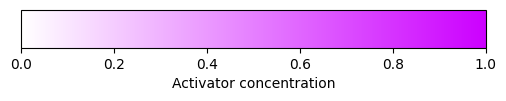

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Create custom colormap: fixed hue=0.8, value=1, saturation varies 0→1
hue = 0.8
n = 256
saturation = np.linspace(0, 1, n)
hsv_colors = np.stack([np.full(n, hue), saturation, np.ones(n)], axis=1)
rgb_colors = mcolors.hsv_to_rgb(hsv_colors)

custom_cmap = mcolors.ListedColormap(rgb_colors)

# Create a dummy mappable for the colorbar
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

norm = mcolors.Normalize(vmin=0, vmax=1)
cb = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=custom_cmap),
    cax=ax,
    orientation='horizontal'
)

cb.set_label("Activator concentration")

plt.savefig('Output/Turing/plots/cbar.pdf')
plt.show()